In [3]:
%pip install librosa
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram, stft
import librosa
import librosa.display

# ============================================================
# 1. FUNCIÓN PARA FFT (Espectro de frecuencia)
# ============================================================
def plot_fft(signal, fs, title="Espectro FFT", f_min=0, f_max=None, db_scale=True):
    """
    Calcula y muestra la FFT de una señal.
    
    Parámetros:
    - signal: array, señal en tiempo
    - fs: float, frecuencia de muestreo (Hz)
    - title: str, título del gráfico
    - f_min, f_max: límites en Hz para el eje X
    - db_scale: bool, si True muestra en dB
    """
    N = len(signal)
    # FFT
    fft_vals = np.fft.fft(signal)
    fft_freq = np.fft.fftfreq(N, 1/fs)
    
    # Solo mitad positiva (espectro unilateral)
    half = N // 2
    fft_vals = fft_vals[:half]
    fft_freq = fft_freq[:half]
    
    # Magnitud
    magnitude = np.abs(fft_vals) / N  # Normalización
    if db_scale:
        magnitude = 20 * np.log10(magnitude + 1e-12)  # +1e-12 para evitar log(0)
        ylabel = "Magnitud (dB)"
    else:
        ylabel = "Magnitud (lineal)"
    
    # Graficar
    plt.figure(figsize=(10, 5))
    plt.plot(fft_freq, magnitude)
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    
    if f_max is None:
        f_max = fs / 2
    plt.xlim([f_min, f_max])
    
    plt.tight_layout()
    plt.show()
    
    return fft_freq, magnitude


In [3]:
# ============================================================
# 2. FUNCIÓN PARA STFT (Espectrograma)
# ============================================================
def plot_stft(signal, fs, title="Espectrograma STFT", 
              nperseg=256, noverlap=None, f_min=0, f_max=None, 
              db_scale=True, cmap='viridis'):
    """
    Calcula y muestra el espectrograma usando STFT.
    
    Parámetros:
    - signal: array, señal en tiempo
    - fs: float, frecuencia de muestreo (Hz)
    - nperseg: int, longitud de cada segmento de la ventana
    - noverlap: int, solapamiento (por defecto 50%)
    - f_min, f_max: límites en Hz para el eje Y
    - db_scale: bool, si True muestra en dB
    """
    if noverlap is None:
        noverlap = nperseg // 2
    
    # Calcular STFT
    f, t, Zxx = stft(signal, fs, nperseg=nperseg, noverlap=noverlap)
    
    # Magnitud
    magnitude = np.abs(Zxx)
    if db_scale:
        magnitude = 20 * np.log10(magnitude + 1e-12)
        label = "Magnitud (dB)"
    else:
        label = "Magnitud"
    
    # Graficar
    plt.figure(figsize=(12, 6))
    plt.pcolormesh(t, f, magnitude, shading='gouraud', cmap=cmap)
    plt.ylabel('Frecuencia (Hz)')
    plt.xlabel('Tiempo (s)')
    plt.title(title)
    plt.colorbar(label=label)
    plt.grid(False)
    
    if f_max is None:
        f_max = fs / 2
    plt.ylim([f_min, f_max])
    
    plt.tight_layout()
    plt.show()
    
    return f, t, Zxx


In [4]:
# ============================================================
# 3. FUNCIÓN PARA CQT (Constant Q Transform)
# ============================================================
def plot_cqt(signal, fs, title="CQT (Constant Q Transform)",
             f_min=None, f_max=None, n_bins=84, bins_per_octave=12,
             db_scale=True, cmap='viridis'):
    """
    Calcula y muestra la CQT (Transformada Q Constante).
    
    Parámetros:
    - signal: array, señal en tiempo
    - fs: float, frecuencia de muestreo (Hz)
    - f_min: frecuencia mínima (Hz), por defecto C2 (~65.4 Hz)
    - f_max: frecuencia máxima (Hz), por defecto fs/2
    - n_bins: número total de bins
    - bins_per_octave: bins por octava (12 = semitonos)
    - db_scale: bool, si True muestra en dB
    """
    # Valores por defecto
    if f_min is None:
        f_min = librosa.note_to_hz('C2')  # ~65.4 Hz
    if f_max is None:
        f_max = fs / 2
    
    # Calcular CQT con librosa
    cqt_vals = librosa.cqt(signal, sr=fs, hop_length=512,
                           fmin=f_min, n_bins=n_bins,
                           bins_per_octave=bins_per_octave)
    
    # Magnitud
    magnitude = np.abs(cqt_vals)
    if db_scale:
        magnitude = 20 * np.log10(magnitude + 1e-12)
        label = "Magnitud (dB)"
    else:
        label = "Magnitud"
    
    # Escala de tiempo
    times = librosa.times_like(cqt_vals, sr=fs, hop_length=512)
    
    # Frecuencias correspondientes
    freqs = librosa.cqt_frequencies(n_bins, fmin=f_min,
                                    bins_per_octave=bins_per_octave)
    
    # Graficar
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(magnitude, sr=fs, hop_length=512,
                             x_axis='time', y_axis='cqt_hz',
                             fmin=f_min, bins_per_octave=bins_per_octave,
                             cmap=cmap)
    plt.colorbar(label=label)
    plt.title(title)
    plt.ylabel('Frecuencia (Hz)')
    plt.xlabel('Tiempo (s)')
    
    # Ajustar límite superior
    if f_max:
        plt.ylim([f_min, f_max])
    
    plt.tight_layout()
    plt.show()
    
    return freqs, times, cqt_vals


In [5]:
# ============================================================
# 4. FUNCIÓN COMPARATIVA (FFT + STFT + CQT)
# ============================================================
def compare_transforms(signal, fs, title_prefix="Señal", 
                       f_min_cqt=65, nperseg=256):
    """
    Muestra los tres análisis (FFT, STFT y CQT) en una sola figura.
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # --- FFT ---
    N = len(signal)
    fft_vals = np.fft.fft(signal)[:N//2]
    fft_freq = np.fft.fftfreq(N, 1/fs)[:N//2]
    mag_fft = 20 * np.log10(np.abs(fft_vals)/N + 1e-12)
    
    axes[0].plot(fft_freq, mag_fft)
    axes[0].set_xlabel('Frecuencia (Hz)')
    axes[0].set_ylabel('Magnitud (dB)')
    axes[0].set_title(f'{title_prefix} - FFT')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim([0, fs/2])
    
    # --- STFT ---
    f, t, Zxx = stft(signal, fs, nperseg=nperseg)
    mag_stft = 20 * np.log10(np.abs(Zxx) + 1e-12)
    
    pcm = axes[1].pcolormesh(t, f, mag_stft, shading='gouraud', cmap='viridis')
    axes[1].set_xlabel('Tiempo (s)')
    axes[1].set_ylabel('Frecuencia (Hz)')
    axes[1].set_title(f'{title_prefix} - STFT')
    axes[1].set_ylim([0, fs/2])
    plt.colorbar(pcm, ax=axes[1], label='Magnitud (dB)')
    
    # --- CQT ---
    cqt_vals = librosa.cqt(signal, sr=fs, hop_length=512,
                           fmin=f_min_cqt, n_bins=60,
                           bins_per_octave=12)
    mag_cqt = 20 * np.log10(np.abs(cqt_vals) + 1e-12)
    
    librosa.display.specshow(mag_cqt, sr=fs, hop_length=512,
                             x_axis='time', y_axis='cqt_hz',
                             fmin=f_min_cqt, bins_per_octave=12,
                             ax=axes[2], cmap='viridis')
    axes[2].set_title(f'{title_prefix} - CQT')
    axes[2].set_xlabel('Tiempo (s)')
    axes[2].set_ylabel('Frecuencia (Hz)')
    plt.colorbar(pcm, ax=axes[2], label='Magnitud (dB)')
    
    plt.tight_layout()
    plt.show()


=== ANÁLISIS DE SEÑAL DE COMUNICACIONES ===

1. Mostrando FFT...


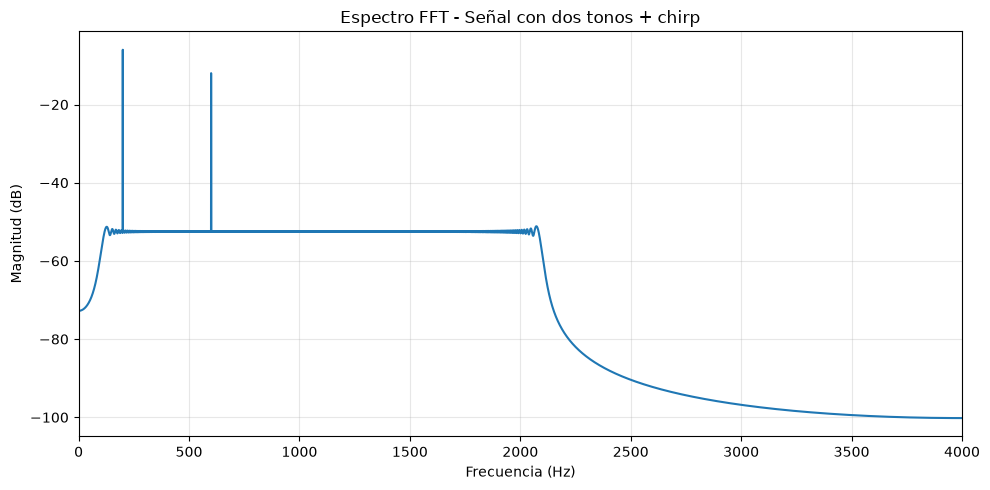


2. Mostrando STFT...


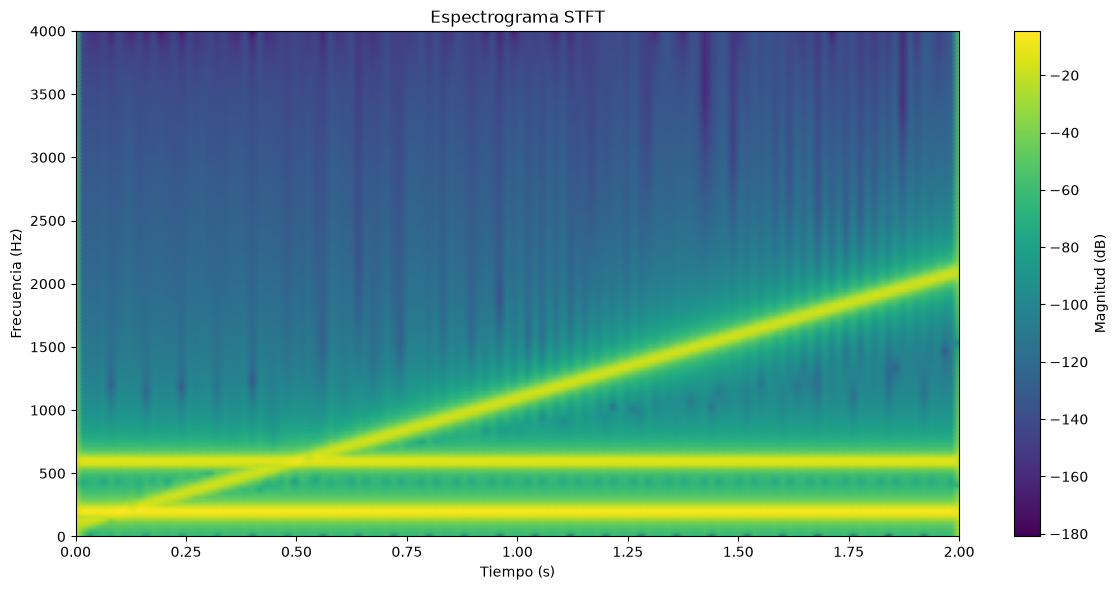


3. Mostrando CQT...


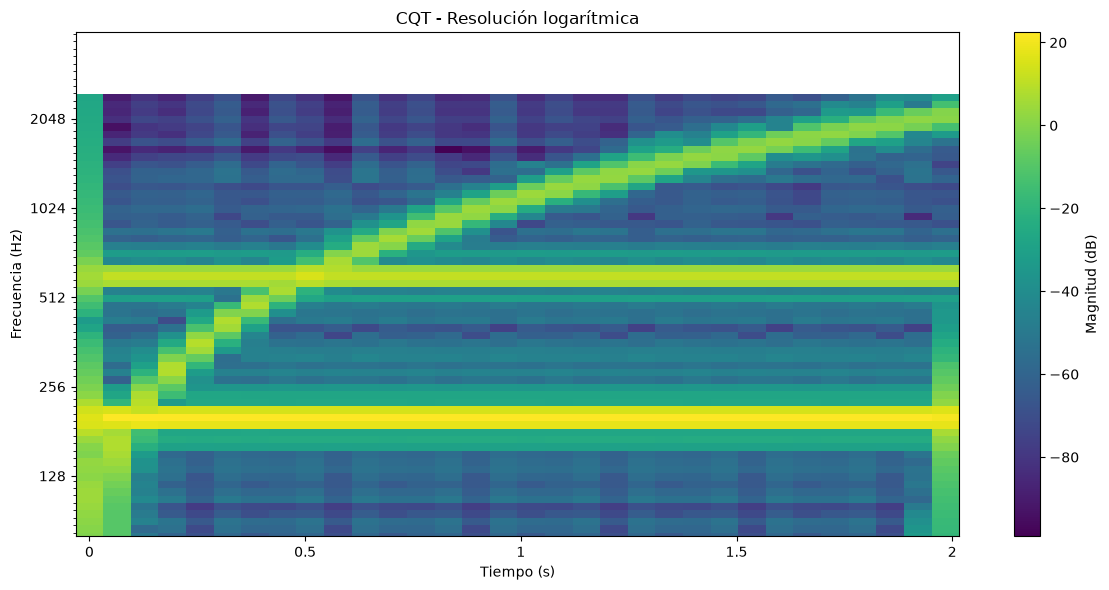


4. Comparativa de los tres métodos...


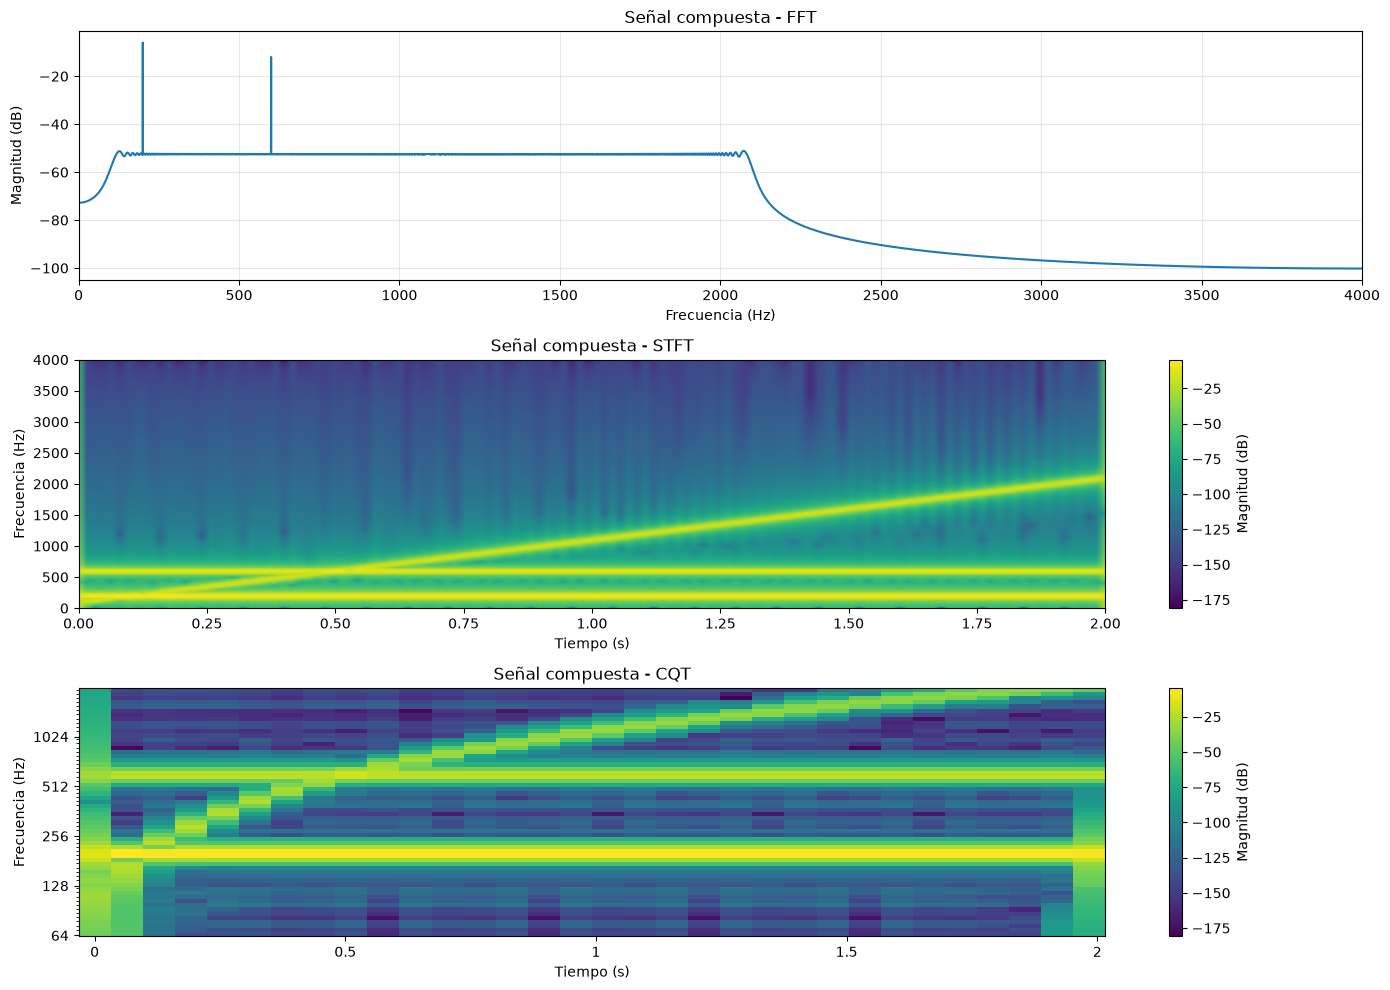

In [6]:
# ============================================================
# EJEMPLO DE USO
# ============================================================
if __name__ == "__main__":
    # Parámetros
    fs = 8000  # 8 kHz
    t = np.linspace(0, 2, fs*2, endpoint=False)
    
    # Señal: dos tonos + chirp (para simular modulación)
    f1, f2 = 200, 600
    signal = np.sin(2*np.pi*f1*t) + 0.5*np.sin(2*np.pi*f2*t)
    
    # Añadir un chirp (barrido de frecuencia) para ver variación temporal
    chirp = np.sin(2*np.pi * (100 + 500*t) * t)
    signal += 0.3 * chirp
    
    print("=== ANÁLISIS DE SEÑAL DE COMUNICACIONES ===\n")
    
    # 1. FFT
    print("1. Mostrando FFT...")
    plot_fft(signal, fs, title="Espectro FFT - Señal con dos tonos + chirp")
    
    # 2. STFT
    print("\n2. Mostrando STFT...")
    plot_stft(signal, fs, title="Espectrograma STFT", nperseg=256)
    
    # 3. CQT
    print("\n3. Mostrando CQT...")
    plot_cqt(signal, fs, title="CQT - Resolución logarítmica", 
             f_min=80, n_bins=60)
    
    # 4. Comparativa
    print("\n4. Comparativa de los tres métodos...")
    compare_transforms(signal, fs, title_prefix="Señal compuesta")
    